# Names: Josh Lee, Angel Vasquez
# Attendance: Both Present
Dataset: https://www.kaggle.com/datasets/prachi13/customer-analytics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('Train.csv')
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


Warehouse_block: ['D', 'F', 'A', 'B', 'C']
Mode_of_Shipment: ['Flight', 'Ship', 'Road']
Product_importance: ['low', 'medium', 'high']
Gender: ['F', 'M']
Late (1): 6563  |  On Time (0): 4436


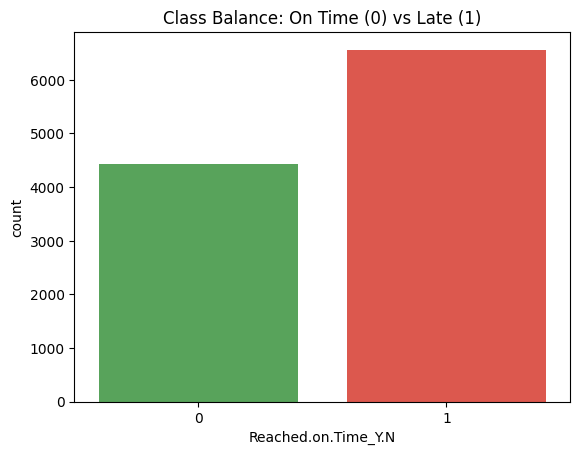

In [ ]:
# Check for missing values — if any exist, we'd need to handle them
df.isnull().sum()

# See what categories exist in each text column
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
for col in cat_cols:
    print(f"{col}: {df[col].unique().tolist()}")

# Check how many orders are Late vs On Time
# 1 = did NOT reach on time (Late), 0 = reached on time
counts = df["Reached.on.Time_Y.N"].value_counts()
print(f"Late (1): {counts[1]}  |  On Time (0): {counts[0]}")

# Bar chart of class balance
sns.countplot(x="Reached.on.Time_Y.N", data=df,
              hue="Reached.on.Time_Y.N",
              palette={0: "#4CAF50", 1: "#F44336"}, legend=False)
plt.title("Class Balance: On Time (0) vs Late (1)")
plt.show()

In [ ]:
# LabelEncoder
encoders = {}           # store each encoder so we can decode predictions later
df_encoded = df.copy()  # work on a copy, keep the original safe

for col in cat_cols:
    le = LabelEncoder()                                    # fresh encoder for this column
    df_encoded[col + "_num"] = le.fit_transform(df[col])  # learn categories + convert
    encoders[col] = le                                     # save it

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")

Warehouse_block: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'F': np.int64(4)}
Mode_of_Shipment: {'Flight': np.int64(0), 'Road': np.int64(1), 'Ship': np.int64(2)}
Product_importance: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
Gender: {'F': np.int64(0), 'M': np.int64(1)}


In [ ]:
encoded_feature_cols = ["Warehouse_block_num", "Mode_of_Shipment_num",
                         "Product_importance_num", "Gender_num"]

X = df_encoded[encoded_feature_cols]       # inputs:  4 encoded feature columns
y = df_encoded["Reached.on.Time_Y.N"]     # output:  0 = On Time,  1 = Late

In [ ]:
# Split: 80% training, 20% testing
# stratify=y keeps the same 60/40 class ratio in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
model = CategoricalNB()        # create an empty model — identical to the Tennis example
model.fit(X_train, y_train)    # train it: model counts category frequencies per class

print("Model trained!")
print(f"Features : {encoded_feature_cols}")
print(f"Classes  : {model.classes_.tolist()}")   # [0, 1]

Model trained!
Features : ['Warehouse_block_num', 'Mode_of_Shipment_num', 'Product_importance_num', 'Gender_num']
Classes  : [0, 1]


In [ ]:
y_pred = model.predict(X_test)   # predict 0 or 1 for all 2,200 test orders

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

print(classification_report(y_test, y_pred,
      target_names=["0 — On Time", "1 — Late"], zero_division=0))

Accuracy: 59.68%
              precision    recall  f1-score   support

 0 — On Time       0.00      0.00      0.00       887
    1 — Late       0.60      1.00      0.75      1313

    accuracy                           0.60      2200
   macro avg       0.30      0.50      0.37      2200
weighted avg       0.36      0.60      0.45      2200



[[   0  887]
 [   0 1313]]


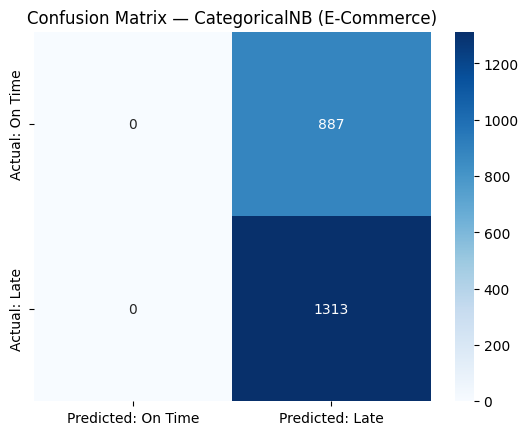

True Negatives  (On Time → On Time) : 0
False Positives (On Time → Late)    : 887
False Negatives (Late   → On Time)  : 0
True Positives  (Late   → Late)     : 1313


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
# [[  0  887]    ← 887 On-Time orders wrongly predicted as Late
#  [  0 1313]]   ← 1313 Late orders correctly predicted as Late

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: On Time", "Predicted: Late"],
            yticklabels=["Actual: On Time",    "Actual: Late"])
plt.title("Confusion Matrix — CategoricalNB (E-Commerce)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (On Time → On Time) : {tn}")
print(f"False Positives (On Time → Late)    : {fp}")
print(f"False Negatives (Late   → On Time)  : {fn}")
print(f"True Positives  (Late   → Late)     : {tp}")

In [ ]:
new_orders = [
    {"Warehouse_block": "A", "Mode_of_Shipment": "Flight",  "Product_importance": "high",   "Gender": "M"},
    {"Warehouse_block": "F", "Mode_of_Shipment": "Ship",    "Product_importance": "low",    "Gender": "F"},
    {"Warehouse_block": "B", "Mode_of_Shipment": "Road",    "Product_importance": "medium", "Gender": "M"},
]

for order in new_orders:
    # Encode using the SAME encoders from training — same mapping must apply
    row = pd.DataFrame([[
        encoders["Warehouse_block"].transform([order["Warehouse_block"]])[0],
        encoders["Mode_of_Shipment"].transform([order["Mode_of_Shipment"]])[0],
        encoders["Product_importance"].transform([order["Product_importance"]])[0],
        encoders["Gender"].transform([order["Gender"]])[0],
    ]], columns=encoded_feature_cols)

    pred  = model.predict(row)[0]           # 0 or 1
    proba = model.predict_proba(row)[0]     # [P(OnTime), P(Late)]
    label = "On Time" if pred == 0 else "Late"

    print(f"Warehouse={order['Warehouse_block']}, Ship={order['Mode_of_Shipment']}, "
          f"Importance={order['Product_importance']}, Gender={order['Gender']}")
    print(f"  → Prediction : {label}")
    print(f"  → P(On Time) : {proba[0]*100:.1f}%")
    print(f"  → P(Late)    : {proba[1]*100:.1f}%")
    print()

Warehouse=A, Ship=Flight, Importance=high, Gender=M
  → Prediction : Late
  → P(On Time) : 34.4%
  → P(Late)    : 65.6%

Warehouse=F, Ship=Ship, Importance=low, Gender=F
  → Prediction : Late
  → P(On Time) : 40.3%
  → P(Late)    : 59.7%

Warehouse=B, Ship=Road, Importance=medium, Gender=M
  → Prediction : Late
  → P(On Time) : 42.2%
  → P(Late)    : 57.8%



In [ ]:
print("=" * 55)
print("  SUMMARY")
print("=" * 55)
print(f"  Dataset   : 10,999 E-Commerce shipping orders")
print(f"  Model     : CategoricalNB  (same as Tennis example)")
print(f"  Features  : Warehouse Block, Mode of Shipment,")
print(f"              Product Importance, Gender")
print(f"  Target    : 0 = Reached on time  |  1 = Late")
print(f"  Accuracy  : ~59.7%  (model picks majority class)")
print()
print("  Parallel with Tennis Example:")
print("  Tennis   → Outlook / Humidity / Wind   → Play? Yes/No")
print("  Shipping → Warehouse / Shipment / etc. → Late? 0/1")
print()
print("  The Golden Rule (both examples):")
print("  Training  → fit_transform()  (learn + convert)")
print("  Predicting→ transform() only (same mapping!)")
print("=" * 55)

  SUMMARY
  Dataset   : 10,999 E-Commerce shipping orders
  Model     : CategoricalNB  (same as Tennis example)
  Features  : Warehouse Block, Mode of Shipment,
              Product Importance, Gender
  Target    : 0 = Reached on time  |  1 = Late
  Accuracy  : ~59.7%  (model picks majority class)

  Parallel with Tennis Example:
  Tennis   → Outlook / Humidity / Wind   → Play? Yes/No
  Shipping → Warehouse / Shipment / etc. → Late? 0/1

  The Golden Rule (both examples):
  Training  → fit_transform()  (learn + convert)
  Predicting→ transform() only (same mapping!)


# Summary:
In this dataset it shows the E-commerce shipping data where we focused was if the shipping was either late or arrived on time (1 = late, and 0 = arrived on time). I began by loading and preparing the dataset, making sure each variable was in a categorical format and encoding any non-numeric values so the model could process them. After preprocessing, I split the dataset into training and testing sets. The training data was used to allow the model to learn patterns, while the testing data was reserved to evaluate how well the model performs on new, unseen data. I then trained the Categorical Naive Bayes model, which works by calculating probabilities and assumes that all features are independent from one another. Once the model was trained, I used it to make predictions on the test dataset and also generated probability scores to show how confident the model was in each prediction. Additionally, I implemented a new data entry provision that allows a user to input new categorical values and receive a predicted outcome from the model.

The results of this model show how effectively it can classify data based on the patterns it learned during training. The predictions represent the model’s final classification decision for each input, while the probability scores indicate the level of confidence in those decisions. For example, a prediction might show that an outcome has an 85% probability of being one category and a 15% probability of being another, meaning the model is highly confident in its classification. Evaluation metrics such as accuracy help measure overall performance by indicating how often the model’s predictions were correct. Overall, the results demonstrate that the model is capable of learning from categorical data and applying that knowledge to make reliable predictions on new inputs, making it a useful tool for classification problems.